# DiffPO Confounding Diffusion Analysis

Compares DDIM denoising trajectories between DiffPO trained on clean IHDP (`naive_full`) and
DiffPO trained on confounded IHDP (`naive_conf`).

## Setup

Loads the config and the two trained DiffPO checkpoints (clean vs. confounded IHDP), loads
both datasets, and runs the DDIM trajectories and point-estimate samples used by the claims
below over the **full IHDP test split**. Every claim is reported stratified by `momblack`
(flipped vs. control) rather than on a balanced subsample.

In [119]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import torch
import yaml
from matplotlib.axes import Axes
from mpl_toolkits.mplot3d.axes3d import Axes3D
from scipy.stats import gaussian_kde, linregress, permutation_test

from src.config import Config
from src.data import load_ihdp, make_ihdp_confounded
from src.model import DiffPO, _DiffusionBase

In [120]:
CLEAN_CHECKPOINT = "checkpoints/final_model_naive_full_2026-08-03T16_21_12.pth"
CONF_CHECKPOINT = "checkpoints/final_model_naive_conf_2026-08-21T12_31_09_rep1.pth"
SEED = 0
N_BOOT = 2000  # bootstrap resamples for the claim-2 CI bands
N_PERM = 10000  # permutation resamples for the claim-3 between-group test

In [121]:
with open("config/ihdp.yaml") as f:
    cfg = Config.model_validate(yaml.safe_load(f))

clean_model = DiffPO(cfg.vae, cfg.diffusion)
clean_model.load_state_dict(torch.load(CLEAN_CHECKPOINT, map_location="cpu"))
clean_model.eval()

conf_model = DiffPO(cfg.vae, cfg.diffusion)
conf_model.load_state_dict(torch.load(CONF_CHECKPOINT, map_location="cpu"))
conf_model.eval()

assert clean_model.L == conf_model.L == cfg.diffusion.num_steps, (
    "Model L values and config L value do not match"
)
print("clean_model.L:", clean_model.L, "  conf_model.L:", conf_model.L)

clean_model.L: 200   conf_model.L: 200


In [122]:
train_ds_clean, val_ds_clean, test_ds_clean, y_std = load_ihdp(
    cfg.data.path,
    replication=cfg.data.replication,
    train_ratio=cfg.data.train_ratio,
    test_ratio=cfg.data.test_ratio,
)
train_ds_conf, val_ds_conf, test_ds_conf = (
    make_ihdp_confounded(ds, effect=cfg.data.confounder_effect)
    for ds in (train_ds_clean, val_ds_clean, test_ds_clean)
)


def _clip_value(train_ds):
    if not cfg.diffusion.clip_denoised:
        return None
    y_both = _DiffusionBase._assemble_yboth(train_ds.a, train_ds.y, train_ds.y_cf)
    return 2 * y_both.abs().max().item()


clip_value_clean = _clip_value(train_ds_clean)
clip_value_conf = _clip_value(train_ds_conf)
print("clip_value_clean:", clip_value_clean, "  clip_value_conf:", clip_value_conf)

clip_value_clean: 6.018764972686768   clip_value_conf: 7.191953659057617


In [123]:
confounder = test_ds_clean.confounder
assert confounder is not None

# Full IHDP test split -- keep every subject. subset_idx stays as the indexer so the rest
# of the notebook is unchanged; all downstream claims are reported stratified by momblack.
subset_idx = np.arange(len(test_ds_clean.x))

momblack_t = torch.as_tensor(confounder[subset_idx])
flipped_mask = momblack_t == 1
control_mask = momblack_t == 0

x = test_ds_clean.x[subset_idx]
a_clean = test_ds_clean.a[subset_idx]
a_conf = test_ds_conf.a[subset_idx]

mu0_clean = test_ds_clean.mu0[subset_idx]
mu1_clean = test_ds_clean.mu1[subset_idx]
mu0_conf = test_ds_conf.mu0[subset_idx]
mu1_conf = test_ds_conf.mu1[subset_idx]

# momblack==0 subjects must see identical (x, a) in both conditions (built-in control group);
# momblack==1 subjects must see exactly-flipped a.
assert torch.equal(a_clean[control_mask], a_conf[control_mask])
assert torch.equal(a_conf[flipped_mask], 1.0 - a_clean[flipped_mask])
assert torch.equal(test_ds_clean.x[subset_idx], test_ds_conf.x[subset_idx])

# mu0/mu1 must also agree on the control group. `make_ihdp_confounded` round-trips them
# through denorm()/renorm() even for momblack==0 subjects (where the shift is a no-op), and
# that float32 round trip is not bit-exact -- the error is relative, so allow rtol as well
# as atol now that the full split reaches larger |mu|.
dev0 = (mu0_clean[control_mask] - mu0_conf[control_mask]).abs().max().item()
dev1 = (mu1_clean[control_mask] - mu1_conf[control_mask]).abs().max().item()
print(f"max |mu_clean - mu_conf| on control group: mu0={dev0:.2e}, mu1={dev1:.2e}")
assert torch.allclose(mu0_clean[control_mask], mu0_conf[control_mask], rtol=1e-5, atol=1e-6)
assert torch.allclose(mu1_clean[control_mask], mu1_conf[control_mask], rtol=1e-5, atol=1e-6)

print(
    f"Test split: {len(subset_idx)} subjects "
    f"({int(flipped_mask.sum())} momblack==1, {int(control_mask.sum())} momblack==0)"
)

max |mu_clean - mu_conf| on control group: mu0=5.96e-08, mu1=1.19e-07
Test split: 148 subjects (75 momblack==1, 73 momblack==0)


In [124]:
print("Clean dataset cross tabulation")
print(
    pd.crosstab(
        test_ds_clean.confounder[subset_idx],
        test_ds_clean.a[subset_idx],
        rownames=["momblack"],
        colnames=["treatment"],
    )
)
print()

print("Confounded dataset cross tabulation:")
print(
    pd.crosstab(
        test_ds_conf.confounder[subset_idx],
        test_ds_conf.a[subset_idx],
        rownames=["momblack"],
        colnames=["treatment"],
    )
)

Clean dataset cross tabulation
treatment  0.0  1.0
momblack           
0.0         42   31
1.0         49   26

Confounded dataset cross tabulation:
treatment  0.0  1.0
momblack           
0.0         42   31
1.0         26   49


In [125]:
torch.manual_seed(SEED)
y_init = torch.randn(len(subset_idx), 2)

y_clean_final, y_clean_traj, eps_clean_traj = clean_model.sample_ddim(
    x, a_clean, y_init=y_init, clip_val=clip_value_clean, log_trajectory=True
)
y_conf_final, y_conf_traj, eps_conf_traj = conf_model.sample_ddim(
    x, a_conf, y_init=y_init, clip_val=clip_value_conf, log_trajectory=True
)

# Compute endpoint distance between the two models' predictions for each subject, i.e.
# how far apart the two models' final generated outputs land, per subject, when both
# start from the exact same noise. Report mean distances overall and by momblack group.
endpoint_dist = (y_clean_final - y_conf_final).norm(dim=1)
endpoint_dist_flipped = endpoint_dist[flipped_mask]
endpoint_dist_control = endpoint_dist[control_mask]

print(
    "Mean endpoint distance (clean vs. confound):",
    endpoint_dist.mean().item(),
    "+/-",
    endpoint_dist.std().item(),
)
print(
    "Endpoint distance, momblack==1:",
    endpoint_dist_flipped.mean().item(),
    "+/-",
    endpoint_dist_flipped.std().item(),
)
print(
    "Endpoint distance, momblack==0:",
    endpoint_dist_control.mean().item(),
    "+/-",
    endpoint_dist_control.std().item(),
)

Mean endpoint distance (clean vs. confound): 2.9909780025482178 +/- 1.9238182306289673
Endpoint distance, momblack==1: 3.107447624206543 +/- 1.8577799797058105
Endpoint distance, momblack==0: 2.8713173866271973 +/- 1.9951188564300537


In [126]:
K = cfg.train.K  # 50, per config/ihdp.yaml -- matches the codebase's normal eval convention

torch.manual_seed(SEED)
y0_clean, y1_clean = clean_model.sample_outcomes(x, a_clean, K=K, clip_val=clip_value_clean)
torch.manual_seed(SEED)
y0_conf, y1_conf = conf_model.sample_outcomes(x, a_conf, K=K, clip_val=clip_value_conf)

# Per-subject point-estimate errors -- how far off each model's predicted POs are from the
# true simulated values.
# `err_clean` is a reference/sanity value only -- claim 3 (below) analyses `err_conf` against
# divergence, and `err_clean` has no analogous divergence quantity to compare against.
err_clean = (
    (y0_clean.mean(dim=1) - mu0_clean).abs() + (y1_clean.mean(dim=1) - mu1_clean).abs()
) / 2
err_conf = (
    (y0_conf.mean(dim=1) - mu0_conf).abs() + (y1_conf.mean(dim=1) - mu1_conf).abs()
) / 2

print("MAE clean:", err_clean.mean().item())
print("MAE confound:", err_conf.mean().item())
print("MAE clean, momblack==1:", err_clean[flipped_mask].mean().item())
print("MAE clean, momblack==0:", err_clean[control_mask].mean().item())
print("MAE confound, momblack==1:", err_conf[flipped_mask].mean().item())
print("MAE confound, momblack==0:", err_conf[control_mask].mean().item())

MAE clean: 0.7731972932815552
MAE confound: 1.5577703714370728
MAE clean, momblack==1: 0.727678656578064
MAE clean, momblack==0: 0.8199630975723267
MAE confound, momblack==1: 1.6590559482574463
MAE confound, momblack==0: 1.4537100791931152


In [127]:
# --- Stratified-analysis helpers (claims 1-3) ----------------------------------------
# Claims below are reported per momblack group (flipped vs. control). Where a single
# number could mislead, a resampling interval or test accompanies it.


def boot_curve(values: np.ndarray, n_boot: int, rng: np.random.Generator) -> np.ndarray:
    """Bootstrap the per-tau mean of `values` (L, n) over its n subjects.

    Resamples subjects with replacement; returns (L, n_boot). Used for the pointwise CI
    bands on the claim-2 divergence-vs-tau curves.
    """
    n = values.shape[1]
    return np.stack(
        [values[:, rng.integers(0, n, n)].mean(axis=1) for _ in range(n_boot)],
        axis=1,
    )


def pointwise_ci(boot: np.ndarray, alpha: float = 0.05) -> tuple[np.ndarray, np.ndarray]:
    """(lo, hi) percentile band from a (L, n_boot) bootstrap array."""
    return np.percentile(boot, [100 * alpha / 2, 100 * (1 - alpha / 2)], axis=1)

## Claim 1: a footprint exists

Cross-evaluates each model's denoiser on the other model's trajectory to get the
predicted-noise divergence `d_tau` (and its `a_conf`-anchored counterpart `d_tau_prime`),
then reports its size relative to the denoiser's own output norm -- overall and split by
`momblack`.

In [128]:
def cross_evaluate(
    other_model: _DiffusionBase,
    y_traj: torch.Tensor,
    x_cond: torch.Tensor,
    a_cond: torch.Tensor,
) -> torch.Tensor:
    """Compute `other_model`'s eps_theta at every (y_traj[i], tau=L-1-i) pair.

    i.e. the same states the *anchor* trajectory visited, cross-evaluated on
    `other_model`'s denoiser with the anchor's own (x_cond, a_cond) held fixed.

    y_traj: (L,N,2). Returns eps: (L,N,2).
    """
    L, N, _ = y_traj.shape
    tau_grid = torch.arange(L - 1, -1, -1).unsqueeze(1).expand(L, N).reshape(-1)
    y_flat = y_traj.reshape(L * N, 2)
    x_flat = x_cond.unsqueeze(0).expand(L, N, -1).reshape(L * N, -1)
    a_flat = a_cond.unsqueeze(0).expand(L, N).reshape(-1)
    with torch.no_grad():
        eps_flat = other_model.denoiser(y_flat, tau_grid, x_flat, a_flat)
    return eps_flat.reshape(L, N, 2)


# d_tau: anchored on the clean trajectory, both terms use a_clean
eps_conf_on_clean = cross_evaluate(conf_model, y_clean_traj, x, a_clean)
d_tau = eps_conf_on_clean - eps_clean_traj

# d_tau': anchored on the confound trajectory, both terms use a_conf
eps_clean_conf = cross_evaluate(clean_model, y_conf_traj, x, a_conf)
d_tau_prime = eps_conf_traj - eps_clean_conf

# Cross-evaluated predicted-noise divergence signals
d_tau_norm = d_tau.norm(dim=-1)  # (L, N)
d_tau_prime_norm = d_tau_prime.norm(dim=-1)  # (L, N)

In [ ]:
eps_clean_norm = eps_clean_traj.norm(dim=-1)  # (L, N)
eps_conf_norm = eps_conf_traj.norm(dim=-1)  # (L, N)

# Is the disagreement non-trivial relative to the size of eps_theta itself?
groups = [
    ("overall", slice(None)),
    ("momblack=1", flipped_mask),
    ("momblack=0", control_mask),
]


def _ratio(div_norm: torch.Tensor, eps_norm: torch.Tensor, mask: torch.Tensor | None) -> float:
    return (div_norm[:, mask].mean() / eps_norm[:, mask].mean()).item()


print("Ratio: mean||d_tau||  / mean||eps_theta(clean)||")
for label, mask in groups:
    print(f"  {label:11s} {_ratio(d_tau_norm, eps_clean_norm, mask):.4f}")

print("\nRatio: mean||d_tau'|| / mean||eps_theta(conf)||")
for label, mask in groups:
    print(f"  {label:11s} {_ratio(d_tau_prime_norm, eps_conf_norm, mask):.4f}")

Ratio  mean||d_tau||  / mean||eps_theta(clean)||
  overall     1.5391
  momblack=1  1.6642
  momblack=0  1.4151

Ratio  mean||d_tau'|| / mean||eps_theta(conf)||
  overall     1.5082
  momblack=1  1.4013
  momblack=0  1.6205


`d_tau` and `d_tau_prime`: if they look similar, the disagreement is a property of the region both data manifolds share

## Claim 2: when it appears

`d_tau` and `d_tau_prime` vs. the diffusion timestep $\tau$, split by `momblack`, with
pointwise 95% bootstrap CI bands -- plus a $\text{flipped}-\text{control}$ difference curve  -- to see
where in the reverse trajectory the divergence concentrates and whether the flipped-subject
excess is localised in $\tau$. The difference curve's band is pointwise only; the
multiplicity-free "flipped > control" statement is the permutation test in claim 3 (the same
contrast, collapsed over $\tau$).

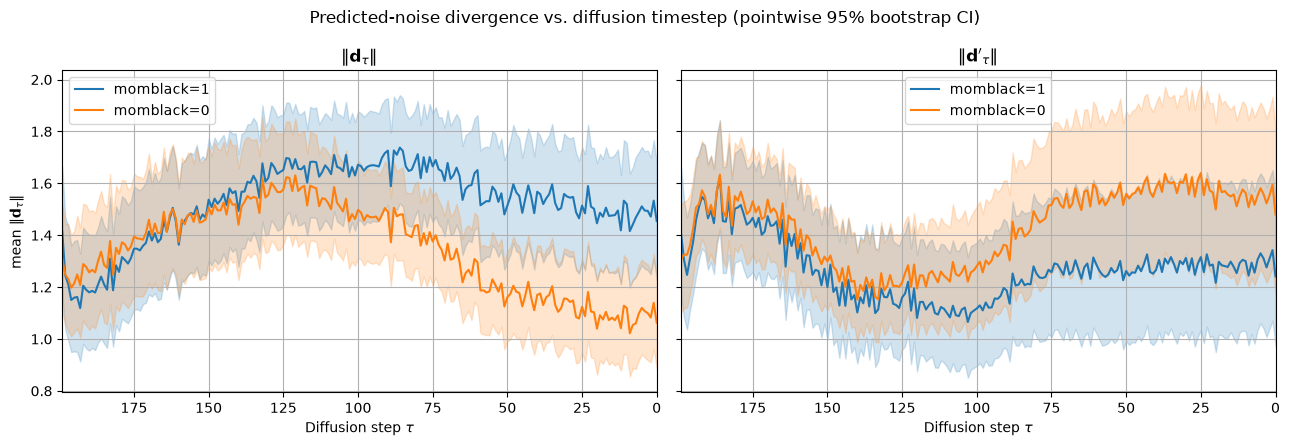

In [130]:
tau_axis = np.arange(cfg.diffusion.num_steps - 1, -1, -1)  # L-1 .. 0, matches trajectory order

dn, dnp = d_tau_norm.numpy(), d_tau_prime_norm.numpy()
fm, cm = flipped_mask.numpy(), control_mask.numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, vals, symbol in [
    (axes[0], dn, r"\mathbf{d}_\tau"),
    (axes[1], dnp, r"\mathbf{d}'_\tau"),
]:
    for mask, label, colour in [(fm, "momblack=1", "C0"), (cm, "momblack=0", "C1")]:
        boot = boot_curve(vals[:, mask], N_BOOT, np.random.default_rng(SEED))
        lo, hi = pointwise_ci(boot)
        ax.plot(tau_axis, vals[:, mask].mean(axis=1), color=colour, label=label)
        ax.fill_between(tau_axis, lo, hi, color=colour, alpha=0.2)
    ax.set_xlim(tau_axis.max(), tau_axis.min())  # tau: L -> 0
    ax.set_xlabel(r"Diffusion step $\tau$")
    ax.set_title(rf"$\|{symbol}\|$")
    ax.grid()
    ax.legend()

axes[0].set_ylabel(r"mean $\|\mathbf{d}_\tau\|$")
fig.suptitle("Predicted-noise divergence vs. diffusion timestep (pointwise 95% bootstrap CI)")
fig.tight_layout()
fig.savefig("images/confounding_divergence_vs_tau.png", dpi=150)
plt.show()

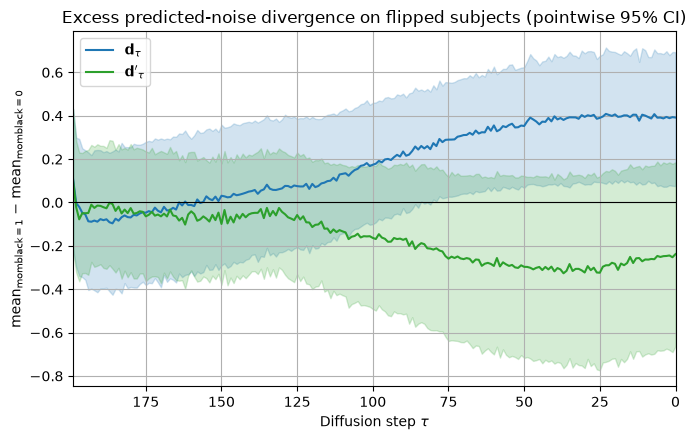

In [131]:
# Excess divergence on flipped subjects: mean_{momblack=1} - mean_{momblack=0} at each tau,
# resampling each group independently. Pointwise CI only (see the claim-2 note).
fig, ax = plt.subplots(figsize=(7, 4.5))
for vals, label, colour in [
    (dn, r"$\mathbf{d}_\tau$", "C0"),
    (dnp, r"$\mathbf{d}'_\tau$", "C2"),
]:
    rng = np.random.default_rng(SEED)
    diff_boot = boot_curve(vals[:, fm], N_BOOT, rng) - boot_curve(vals[:, cm], N_BOOT, rng)
    lo, hi = pointwise_ci(diff_boot)
    obs = vals[:, fm].mean(axis=1) - vals[:, cm].mean(axis=1)
    ax.plot(tau_axis, obs, color=colour, label=label)
    ax.fill_between(tau_axis, lo, hi, color=colour, alpha=0.2)

ax.axhline(0.0, color="k", lw=0.8)
ax.set_xlim(tau_axis.max(), tau_axis.min())
ax.set_xlabel(r"Diffusion step $\tau$")
ax.set_ylabel(r"mean$_{\mathrm{momblack}=1}$ $-$ mean$_{\mathrm{momblack}=0}$")
ax.set_title("Excess predicted-noise divergence on flipped subjects (pointwise 95% CI)")
ax.legend()
ax.grid()
fig.tight_layout()
fig.savefig("images/confounding_divergence_diff_vs_tau.png", dpi=150)
plt.show()

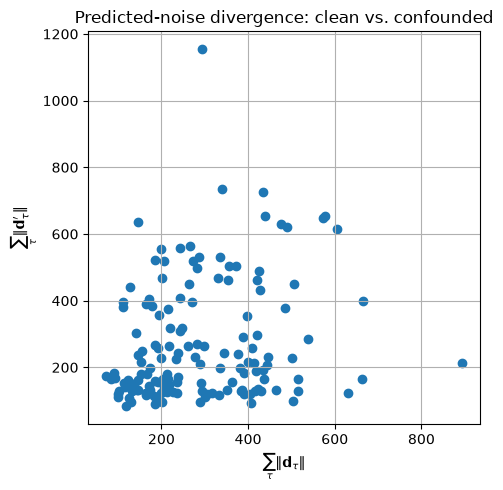

Pearson correlation between ||d_tau|| and ||d_tau'||: 0.2232


In [132]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(d_tau_norm.sum(dim=0).numpy(), d_tau_prime_norm.sum(dim=0).numpy())
plt.xlabel(r"$\sum_\tau \|\mathbf{d}_\tau\|$")
plt.ylabel(r"$\sum_\tau \|\mathbf{d}_\tau'\|$")
plt.title("Predicted-noise divergence: clean vs. confounded")
plt.grid()
plt.tight_layout()
plt.show()

corr = np.corrcoef(d_tau_norm.sum(dim=0).numpy(), d_tau_prime_norm.sum(dim=0).numpy())[0, 1]
print(f"Pearson correlation between ||d_tau|| and ||d_tau'||: {corr:.4f}")

Per-subject divergence on the two anchors is only weakly related on the full split (Pearson
$r \approx 0.22$) -- so which trajectory the disagreement is measured along matters, consistent
with the anchor-dependent sign flip in the claim-2 difference curve above.

## Claim 3: does it predict harm?

Per-subject divergence $\sum_\tau \|\mathbf{d}_\tau\|$ against the confounded model's
point-estimate error vs. ground truth, three ways:

1. **Within-group Pearson correlation** (flipped / control separately) -- a pooled
   correlation is confounded by the between-group mean shift (Simpson's paradox);
2. **OLS** `err ~ divergence * momblack` with HC3 robust SEs (`err_conf` is an absolute
   error, so its residual variance grows with the fitted mean). Divergence is grand-centred,
   so the `momblack` coefficient is the group gap at mean divergence and the interaction is
   the slope difference -- the quantity the claim is really about;
3. A **permutation test** on the between-group difference in mean per-subject divergence.

`err_conf` is also a K=50 Monte-Carlo estimate, so it carries estimation noise in the
regression's *outcome*: this attenuates the correlations without biasing the slopes, so a
weak-but-nonzero relationship should be read as a lower bound.

momblack=0: within-group Pearson r = -0.144  (p = 0.226, slope = -0.0007, n = 73)
momblack=1: within-group Pearson r = +0.117  (p = 0.318, slope = +0.0005, n = 75)


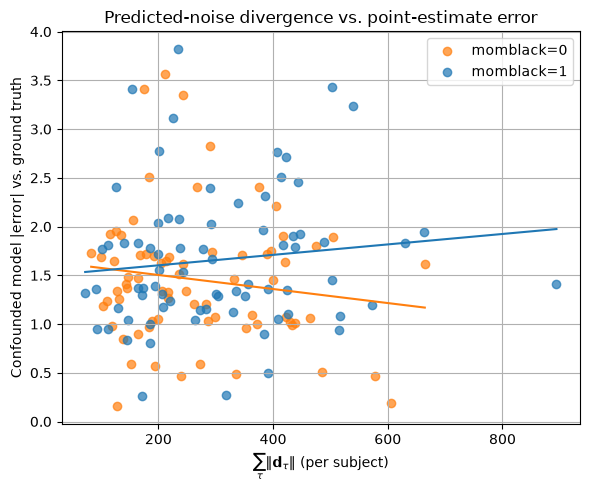


OLS  err_conf ~ divergence_centred * momblack   (divergence grand-centred, HC3 SEs)
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       1.4405      0.080     17.980      0.000       1.283       1.597
divergence_centred             -0.0007      0.001     -1.256      0.209      -0.002       0.000
momblack                        0.2090      0.116      1.807      0.071      -0.018       0.436
divergence_centred:momblack     0.0013      0.001      1.615      0.106      -0.000       0.003

Permutation test  mean divergence (momblack=1 - momblack=0): diff = +36.330, p = 0.124  (10000 resamples)


In [ ]:
subject_divergence = d_tau_norm.sum(dim=0)  # (N,) -- sum_tau ||d_tau|| per subject

div = subject_divergence.numpy()
err = err_conf.numpy()
fm, cm = flipped_mask.numpy(), control_mask.numpy()
mb = fm.astype(float)

# 1. Scatter + within-group Pearson r / OLS fit line
fig, ax = plt.subplots(figsize=(6, 5))
for mask, label, colour in [(cm, "momblack=0", "C1"), (fm, "momblack=1", "C0")]:
    ax.scatter(div[mask], err[mask], color=colour, alpha=0.7, label=label)
    lr = linregress(div[mask], err[mask])
    xs = np.array([div[mask].min(), div[mask].max()])
    ax.plot(xs, lr.intercept + lr.slope * xs, color=colour)
    print(
        f"{label}: within-group Pearson r = {lr.rvalue:+.3f}  "
        f"(p = {lr.pvalue:.3g}, slope = {lr.slope:+.4f}, n = {int(mask.sum())})"
    )
ax.set_xlabel(r"$\sum_\tau \|\mathbf{d}_\tau\|$ (per subject)")
ax.set_ylabel("Confounded model |error| vs. ground truth")
ax.set_title("Predicted-noise divergence vs. point-estimate error")
ax.legend()
ax.grid()
fig.tight_layout()
fig.savefig("images/confounding_divergence_vs_error.png", dpi=150)
plt.show()

# 2. OLS: err ~ divergence_centred * momblack, with HC3 robust SEs (err_conf is an
#    absolute error, so residual variance grows with the fitted mean -- heteroskedastic).
ols_df = pd.DataFrame({"err": err, "divergence_centred": div - div.mean(), "momblack": mb})
ols = smf.ols("err ~ divergence_centred * momblack", data=ols_df).fit(cov_type="HC3")
print("\nOLS  err_conf ~ divergence_centred * momblack   (divergence grand-centred, HC3 SEs)")
print(ols.summary().tables[1])

# 3. Permutation test: between-group difference in mean per-subject divergence
perm = permutation_test(
    (div[fm], div[cm]),
    lambda a, b, axis: a.mean(axis=axis) - b.mean(axis=axis),
    permutation_type="independent",
    alternative="two-sided",
    n_resamples=N_PERM,
    rng=SEED,
)
print(
    f"\nPermutation test -- mean divergence (momblack=1 - momblack=0): "
    f"diff = {perm.statistic:+.3f}, p = {perm.pvalue:.4g}  ({N_PERM} resamples)"
)

## Field + density visualisation

For one momblack==1 and one momblack==0 subject, plots each model's denoising score field
alongside a KDE density surface of y_tau at several snapshot taus. Note: the density
surfaces are built from the stochastic DDPM sampler (`sample_trajectory`), not DDIM as in the
intro above -- a single deterministic DDIM trajectory can't produce a distribution, only
DDPM's independent stochastic draws can.

In [17]:
L_STEPS = cfg.diffusion.num_steps
SNAPSHOT_TAUS = [L_STEPS - 1, 3 * L_STEPS // 4, L_STEPS // 2, L_STEPS // 4, 0]
DENSITY_K = 300
GRID_N = 70
GRID_RANGE = 7.0  # y0, y1 span, in normalised outcome units

subject_flipped = int(np.flatnonzero(flipped_mask.numpy())[0])
subject_control = int(np.flatnonzero(control_mask.numpy())[0])


def tau_to_traj_index(tau: int, L: int) -> int:
    """Trajectory index i logs tau = L-1-i (see _ddim_reverse/_ddpm_reverse docstrings)."""
    return (L - 1) - tau


def eps_grid(
    model: _DiffusionBase,
    tau: int,
    x_subj: torch.Tensor,
    a_subj: torch.Tensor,
    grid_n: int = GRID_N,
    grid_range: float = GRID_RANGE,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """`model`'s eps_theta on a (grid_n, grid_n) grid of y=(y0,y1) at fixed tau.

    This is for one subject.
    """
    lin = torch.linspace(-grid_range, grid_range, grid_n)
    Y0, Y1 = torch.meshgrid(lin, lin, indexing="xy")
    y_grid = torch.stack([Y0.reshape(-1), Y1.reshape(-1)], dim=1)  # (grid_n**2, 2)
    n = y_grid.shape[0]

    # Same (tau, x, a) for all grid points
    tau_t = torch.full((n,), tau, dtype=torch.long)
    x_rep = x_subj.unsqueeze(0).expand(n, -1)
    a_rep = a_subj.unsqueeze(0).expand(n)

    # Get the predicted noise [eps_y(0), eps_y(1)] for each grid point
    with torch.no_grad():
        eps = model.denoiser(y_grid, tau_t, x_rep, a_rep)

    return (
        Y0.numpy(),
        Y1.numpy(),
        eps[:, 0].reshape(grid_n, grid_n).numpy(),
        eps[:, 1].reshape(grid_n, grid_n).numpy(),
    )

In [18]:
def sample_trajectory(
    model: _DiffusionBase,
    x_subj: torch.Tensor,
    a_subj: torch.Tensor,
    clip_val: float,
    seed: int = SEED,
    K: int = DENSITY_K,
) -> torch.Tensor:
    """K independent stochastic reverse-trajectory samples for one subject.

    Returns y_traj (L, K, 2): the state entering each step, in step order from tau=L-1 down
    to tau=0 (see tau_to_traj_index). Sample once per (model, subject) and slice out every
    tau needed from the result, rather than re-running the K-sample ensemble per tau.
    """
    x_rep = x_subj.unsqueeze(0).expand(K, -1)
    a_rep = a_subj.unsqueeze(0).expand(K)

    torch.manual_seed(seed)
    with torch.no_grad():
        _, y_traj, _ = model._ddpm_reverse(
            K, x_rep, a_rep, torch.device("cpu"), clip_val=clip_val, log_trajectory=True
        )

    return y_traj  # (L, K, 2)


def kde_surface(
    samples: torch.Tensor, grid_n: int = GRID_N, grid_range: float = GRID_RANGE
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Fit a 2D Gaussian KDE to `samples` and evaluate it on a regular grid.

    `samples`: (K, 2) cloud of y=(y0,y1) points, e.g. y_tau collected from K stochastic
    reverse trajectories at one snapshot tau.

    Returns (Y0, Y1, Z), each (grid_n, grid_n): the meshgrid coordinates spanning
    [-grid_range, grid_range]^2, and the estimated density p_hat_tau(y) at each node,
    aligned for ax.plot_surface(Y0, Y1, Z).
    """
    kde = gaussian_kde(samples.numpy().T)
    lin = np.linspace(-grid_range, grid_range, grid_n)
    Y0, Y1 = np.meshgrid(lin, lin)
    Z = kde(np.vstack([Y0.ravel(), Y1.ravel()])).reshape(grid_n, grid_n)
    return Y0, Y1, Z


def plot_field_and_density(
    model: _DiffusionBase,
    tau: int,
    x_subj: torch.Tensor,
    a_subj: torch.Tensor,
    clip_val: float,
    title: str,
    density_ax: Axes3D,
    field_ax: Axes | None = None,
    y_traj_samples: torch.Tensor | None = None,
    quiver_field_grid_n: int = GRID_N // 3,
):
    """Plot a KDE density surface on density_ax and score quiver on field_ax it is provided.

    y_traj_samples, if given, is a precomputed (L, K, 2) trajectory ensemble from
    sample_trajectory -- the tau slice is taken from it directly. Otherwise a fresh K-sample
    ensemble is drawn for this call alone (kept for standalone use; the small-multiples loop
    below always passes a precomputed ensemble so all taus in a row share one draw).
    """
    if y_traj_samples is None:
        y_traj_samples = sample_trajectory(model, x_subj, a_subj, clip_val)
    samples = y_traj_samples[tau_to_traj_index(tau, model.L)]  # (K, 2)

    y0_density, y1_density, p_hat = kde_surface(samples)
    density_ax.plot_surface(y0_density, y1_density, p_hat, cmap="viridis", alpha=0.8)

    if field_ax is not None:
        y0_field, y1_field, eps0, eps1 = eps_grid(
            model, tau, x_subj, a_subj, quiver_field_grid_n
        )
        scale = (1.0 - model.alpha_bar_sched[tau]).clamp(min=1e-15).sqrt().item()
        # This is the one place this notebook uses the score instead of the predicted noise,
        # because the score is what points in the direction of higher density. The predicted
        # noise is the negative of the score, scaled by sqrt(1-alpha_bar)
        score0, score1 = -eps0 / scale, -eps1 / scale
        field_ax.quiver(
            y0_field,
            y1_field,
            score0,
            score1,
            # angles="xy",
            # color="black",
        )

    density_ax.set_title(title, y=1.01)
    density_ax.set_xlabel(r"$y(0)$")
    density_ax.set_ylabel(r"$y(1)$")
    density_ax.set_zlabel(r"$\hat p_\tau(y)$")
    if field_ax is not None:
        field_ax.set_xlabel(r"$y(0)$")
        field_ax.set_ylabel(r"$y(1)$")

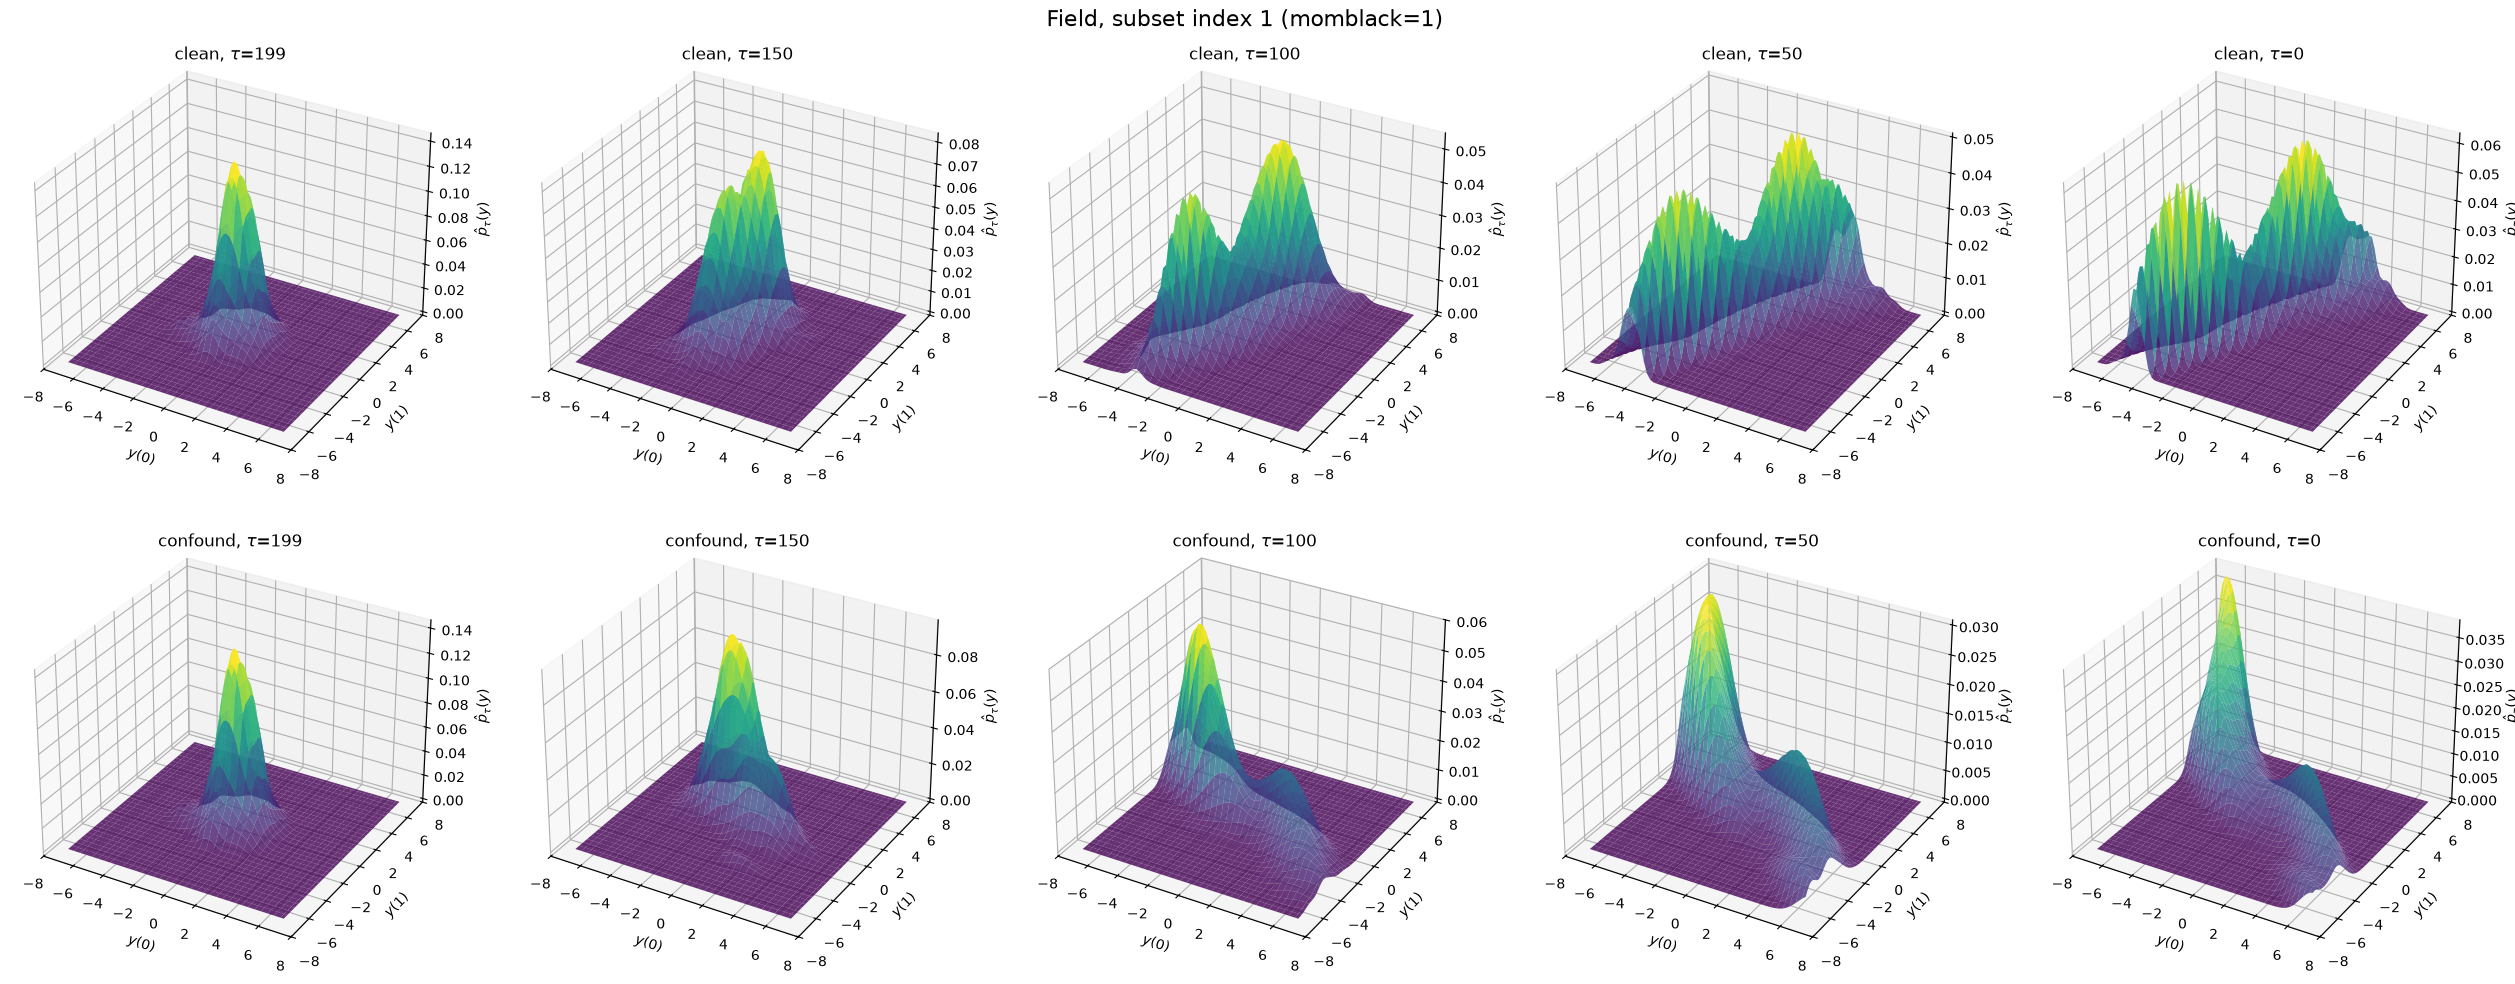

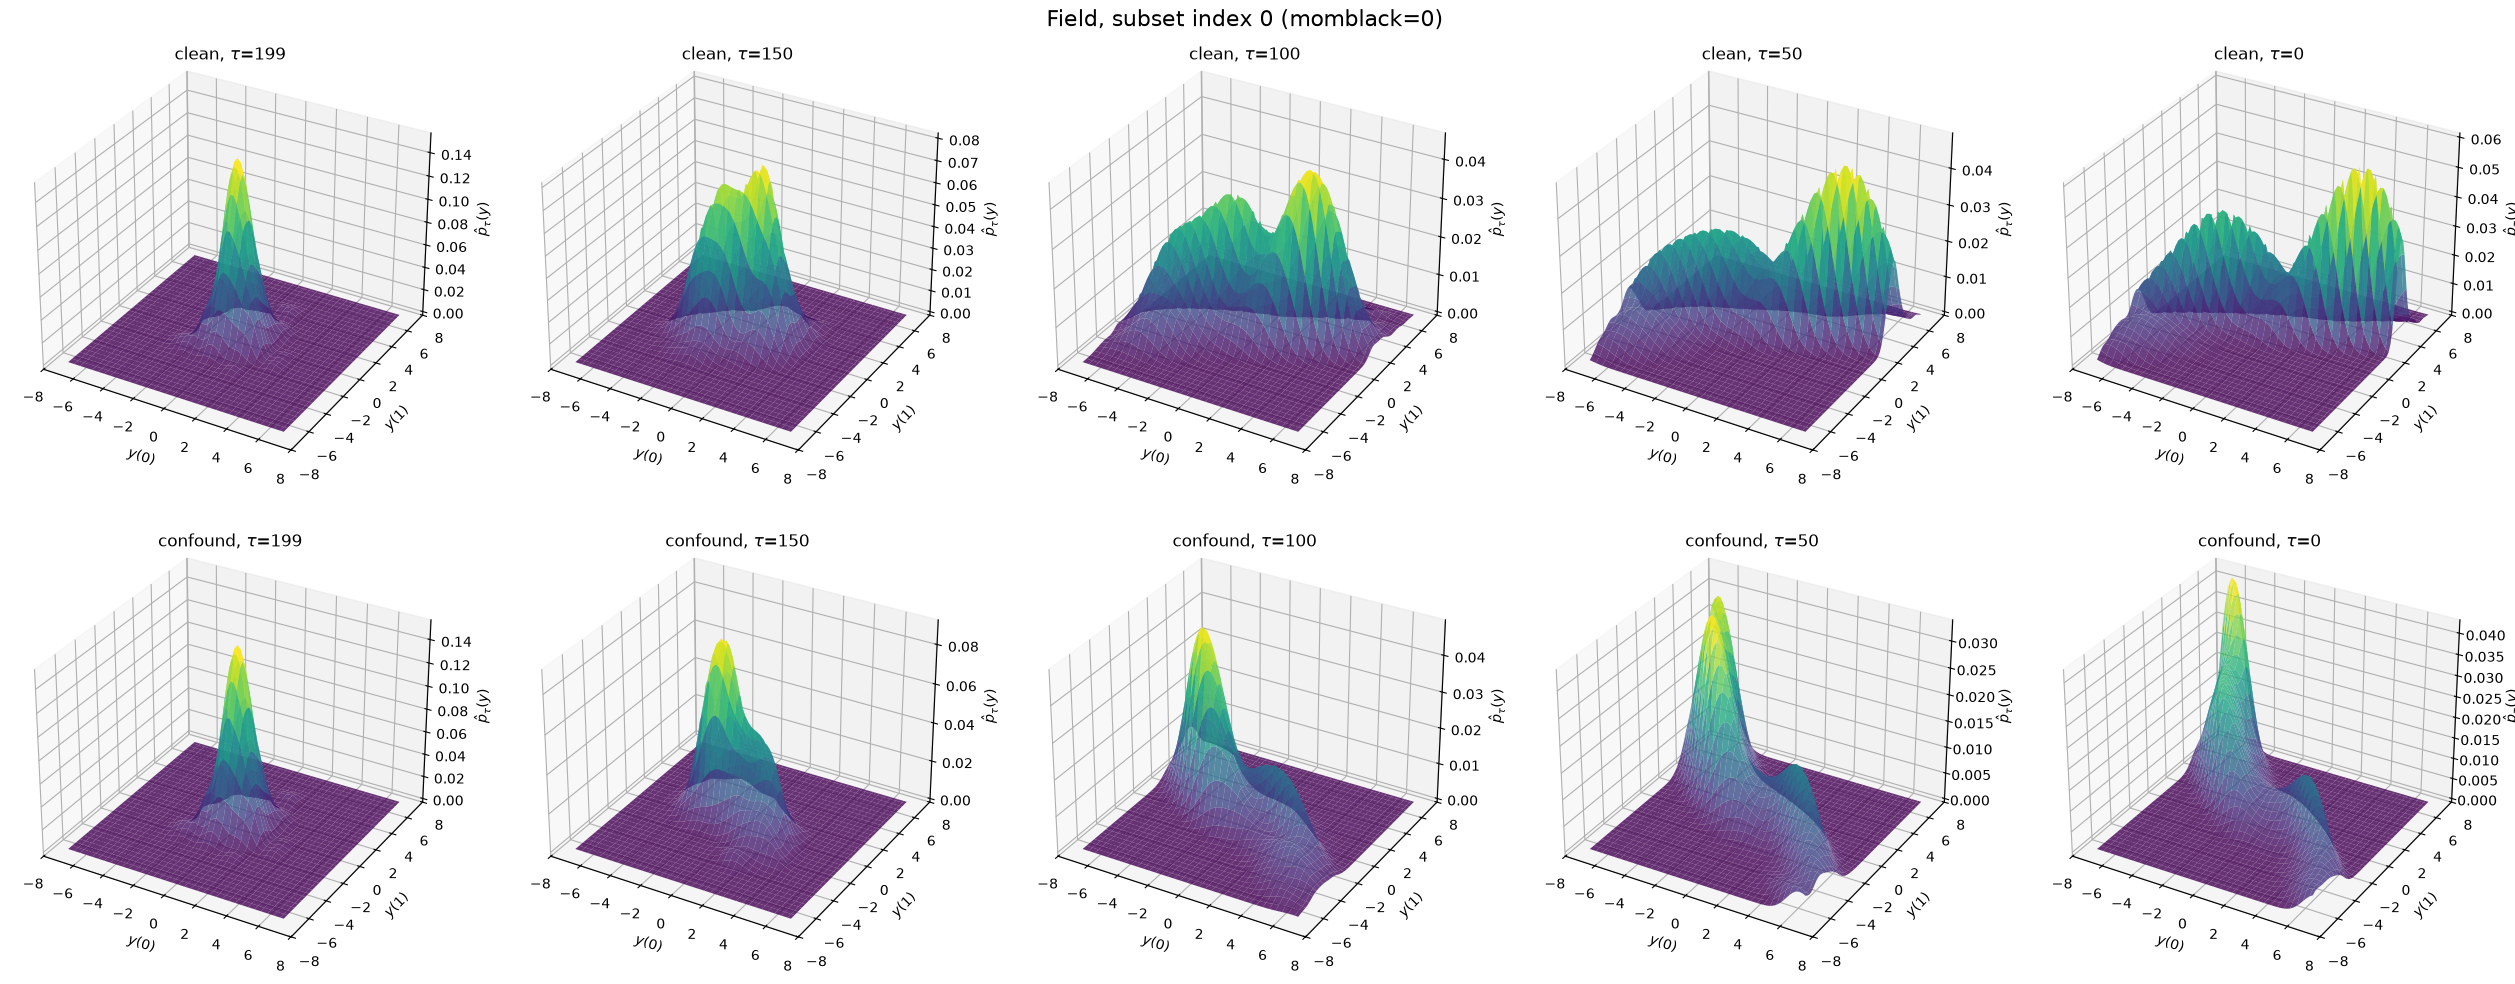

In [19]:
for subj_idx, subj_label in [(subject_flipped, "momblack=1"), (subject_control, "momblack=0")]:
    x_subj, a_clean_subj, a_conf_subj = x[subj_idx], a_clean[subj_idx], a_conf[subj_idx]

    # Sample each model's trajectory ensemble once per subject, then slice every
    # SNAPSHOT_TAUS value below -- one coherent ensemble sliced across time, not a
    # fresh independent draw per (model, tau) pair.
    run_seed = SEED + subj_idx
    clean_traj_samples = sample_trajectory(
        clean_model, x_subj, a_clean_subj, clip_value_clean, run_seed
    )
    conf_traj_samples = sample_trajectory(
        conf_model, x_subj, a_conf_subj, clip_value_conf, run_seed
    )

    fig = plt.figure(figsize=(5 * len(SNAPSHOT_TAUS), 20))
    for col, tau in enumerate(SNAPSHOT_TAUS):
        density_ax_clean = fig.add_subplot(4, len(SNAPSHOT_TAUS), col + 1, projection="3d")
        plot_field_and_density(
            clean_model,
            tau,
            x_subj,
            a_clean_subj,
            clip_value_clean,
            rf"clean, $\tau$={tau}",
            density_ax_clean,
            y_traj_samples=clean_traj_samples,
        )

        density_ax_conf = fig.add_subplot(
            4, len(SNAPSHOT_TAUS), len(SNAPSHOT_TAUS) + col + 1, projection="3d"
        )
        plot_field_and_density(
            conf_model,
            tau,
            x_subj,
            a_conf_subj,
            clip_value_conf,
            rf"confound, $\tau$={tau}",
            density_ax_conf,
            y_traj_samples=conf_traj_samples,
        )

    fig.suptitle(f"Field, subset index {subj_idx} ({subj_label})", fontsize=16)
    fig.tight_layout()
    fig.subplots_adjust(wspace=0.15)
    fig.savefig(
        f"images/confounding_field_density_{subj_label.replace('=', '')}.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

## Difference field visualisation

Plots the standalone difference field d_tau(y) = eps_conf(y) - eps_clean(y) across the
(y0, y1) grid at the same snapshot taus, for the same two subjects.

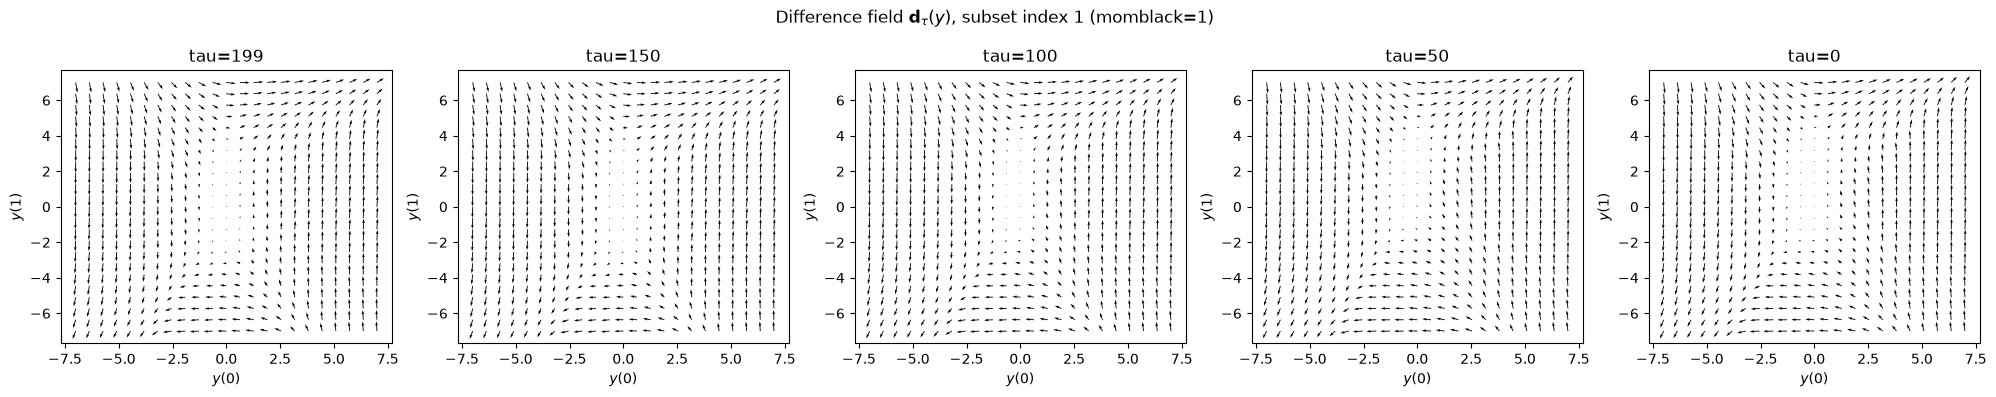

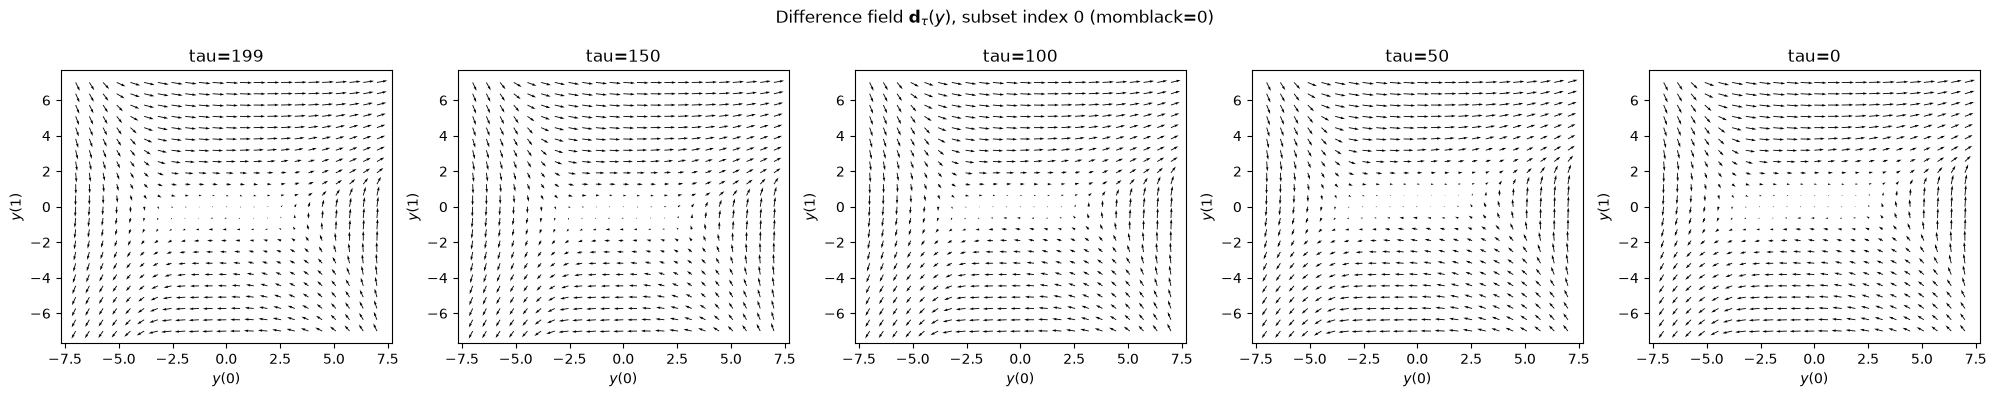

In [20]:
def plot_difference_field(
    tau: int,
    x_subj: torch.Tensor,
    a_anchor_subj: torch.Tensor,
    title: str,
    ax: Axes,
    arrow_grid_n: int = GRID_N // 3,
):
    """Standalone difference field d_tau(y), both terms evaluated with the same
    (anchor) a -- here a_clean.

    Kept as raw eps_theta, not rescaled to the score.
    """
    Y0, Y1, eps0_clean, eps1_clean = eps_grid(
        clean_model, tau, x_subj, a_anchor_subj, grid_n=arrow_grid_n
    )
    _, _, eps0_conf, eps1_conf = eps_grid(
        conf_model, tau, x_subj, a_anchor_subj, grid_n=arrow_grid_n
    )
    d0, d1 = eps0_conf - eps0_clean, eps1_conf - eps1_clean

    ax.quiver(Y0, Y1, d0, d1)
    ax.set_title(title)
    ax.set_xlabel(r"$y(0)$")
    ax.set_ylabel(r"$y(1)$")


for subj_idx, subj_label in [(subject_flipped, "momblack=1"), (subject_control, "momblack=0")]:
    x_subj, a_clean_subj = x[subj_idx], a_clean[subj_idx]

    fig, axes = plt.subplots(1, len(SNAPSHOT_TAUS), figsize=(4 * len(SNAPSHOT_TAUS), 4))
    for ax, tau in zip(axes, SNAPSHOT_TAUS, strict=True):
        plot_difference_field(tau, x_subj, a_clean_subj, f"tau={tau}", ax)
    fig.suptitle(
        rf"Difference field $\mathbf{{d}}_\tau(y)$, subset index {subj_idx} ({subj_label})"
    )
    fig.tight_layout()
    fig.savefig(f"images/confounding_diff_field_{subj_label.replace('=', '')}.png", dpi=150)
    plt.show()